In [1]:
import itertools
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pickle


import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u
from STX3KO_analyses import utilities_ES as u_es
import TwoPUtils as tpu

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'


%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
import pickle 
with open('/home/mplitt/shuffle_pkls/dense_place_field_spatial_shuffle_F_dff.pkl','rb') as file:
    shuff_results = pickle.load(file)

In [3]:
mouse = ctrl_mice[0]
day = 0
ttype = 'nov'
fields_dict = shuff_results[mouse][day][ttype]


In [4]:
fields_dict['rising_edges']

array([[   1,   20],
       [   4,    0],
       [   4,   19],
       ...,
       [1376,   12],
       [1376,   26],
       [1379,    0]], shape=(955, 2))

{'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 6, 'scan': 14, 'novel_arm': -1, 'ravel_ind': 1}


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:232: UserWarning: Could not find sbxmat file at /mnt/BigDisk/2P_scratch/4467975.1/28_09_2020/YMaze_LNovel/YMaze_LNovel_006_014.mat
  warnings.warn("Could not find sbxmat file at %s" % self.scanheader_file)
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:241: UserWarning: Could not find sbx file at /mnt/BigDisk/2P_scratch/4467975.1/28_09_2020/YMaze_LNovel/YMaze_LNovel_006_014.sbx
  warnings.warn("Could not find sbx file at %s" % self.scan_file)


{'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 3, 'scan': 8, 'novel_arm': 1, 'ravel_ind': 0}


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:232: UserWarning: Could not find sbxmat file at /mnt/BigDisk/2P_scratch/4467975.2/28_09_2020/YMaze_LNovel/YMaze_LNovel_003_008.mat
  warnings.warn("Could not find sbxmat file at %s" % self.scanheader_file)
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:241: UserWarning: Could not find sbx file at /mnt/BigDisk/2P_scratch/4467975.2/28_09_2020/YMaze_LNovel/YMaze_LNovel_003_008.sbx
  warnings.warn("Could not find sbx file at %s" % self.scan_file)


{'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'ravel_ind': 0}


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:232: UserWarning: Could not find sbxmat file at /mnt/BigDisk/2P_scratch/4467975.3/28_09_2020/YMaze_LNovel/YMaze_LNovel_001_004.mat
  warnings.warn("Could not find sbxmat file at %s" % self.scanheader_file)
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:241: UserWarning: Could not find sbx file at /mnt/BigDisk/2P_scratch/4467975.3/28_09_2020/YMaze_LNovel/YMaze_LNovel_001_004.sbx
  warnings.warn("Could not find sbx file at %s" % self.scan_file)


{'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 5, 'novel_arm': 1, 'ravel_ind': 0}
{'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '18_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '18_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 0}
(332, 5) (332, 5) (332,)
0.17456976234580387 0.0014062218996160117
0.33720369497238234 2.85175863806311e-10
{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 0}
{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 8, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 18, 'novel_arm': 1, 'ravel_ind': 1}
{'date': '29_11_2020', 'scene': 'YMaze_LNovel',

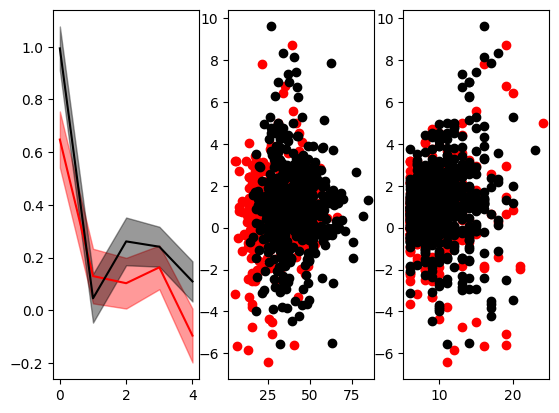

In [ ]:
fig, ax = plt.subplots(1,3)
max_trial = 5
x = np.arange(max_trial)


for cond, mice in zip(('ko','ctrl'), (ko_mice, ctrl_mice)):
# for cond, mice in zip(('ctrl',), ( ctrl_mice,)):
    argmax_mat, formation_laps, fieldspeed_mat, width_mat = [],[], [],[]
    for mouse in mice:
        for day in range(1): 
            sess = u.load_single_day(mouse, day)
            for ttype in ('nov',):
                
                fields_dict = shuff_results[mouse][day][ttype]


                if ttype =='fam':
                    trial_mask = sess.trial_info['LR']!=sess.novel_arm
                else:
                    trial_mask = sess.trial_info['LR']==sess.novel_arm

                trial_mat = sess.trial_matrices['F_dff_th'][trial_mask,:,:]
                trial_mat[np.isnan(trial_mat)]=0
                speed_mat = sess.trial_matrices['speed'][trial_mask,:]

                
                # trial_mat[trial_mat<0]=1E-5

                shifts, inds, fl, speeds, widths = stx.single_field_shifts.get_field_shifts(trial_mat, fields_dict, speed_mat)
                argmax_mat.append(stx.single_field_shifts.shifts_to_matrix(shifts, max_trial))
                fieldspeed_mat.append(stx.single_field_shifts.shifts_to_matrix(speeds, max_trial))
                width_mat.append(widths)
                # argmax_mat.append(stx.single_field_shifts.shifts_to_matrix(shifts, max_trial).mean(axis=0)[np.newaxis,:])
                
                # formation_laps.append(fl)
                # # print(argmax_mat)

                # prop_cells = np.cumsum(np.bincount(fl[:40]))/np.array(fl[:40]).shape[0]
                # if cond == 'ko':
                #     ax.plot(prop_cells, color='red')
                # else:
                #     ax.plot(prop_cells, color='black')

    argmax_mat = np.concatenate(argmax_mat)
    fieldspeed_mat = np.concatenate(fieldspeed_mat)
    width_mat = np.concatenate(width_mat).ravel()
    print(argmax_mat.shape, fieldspeed_mat.shape, width_mat.shape)
    mu, sem = np.nanmean(argmax_mat,axis=0), sp.stats.sem(argmax_mat,axis=0,nan_policy='omit')
    if cond == 'ko':
        color = 'red'
    else:
        color='black'
    # ax.plot(x,argmax_mat.T, color=color)
    ax[0].plot(x, mu, color=color)
    ax[0].fill_between(x, mu-sem, mu+sem, color=color,alpha=.4)

    ax[1].scatter(fieldspeed_mat[:,0], argmax_mat[:,0],color=color)
    r, p = sp.stats.pearsonr(fieldspeed_mat[:,0], argmax_mat[:,0])
    print(r,p)

    ax[2].scatter(fieldspeed_mat[:,0], width_mat, color=color)
    r,p = sp.stats.pearsonr(fieldspeed_mat[:,0],width_mat)
    print(r,p)


In [17]:
import pickle 
with open('/home/mplitt/shuffle_pkls/sparse_place_field_spatial_shuffle_F_dff.pkl','rb') as file:
    shuff_results = pickle.load(file)

In [18]:

x = np.arange(max_trial)


argmax_dict = {}
# argmax_mat, formation_laps, fieldspeed_mat, width_mat = [],[], [],[]
for mouse in sparse_mice:
    argmax_dict[mouse] = {}
    for day in range(1): 
        argmax_dict[mouse][day]={}
        sess = u.load_single_day(mouse, day, pkl_basedir='/home/mplitt/YMazeSessPkls')
        for ttype in ('nov',):
            argmax_dict[mouse][day][ttype] = {}
            
            for chan in ('channel_0', 'channel_1'):
            
                fields_dict = shuff_results[mouse][chan][day][ttype]


                if ttype =='fam':
                    trial_mask = sess.trial_info['LR']!=sess.novel_arm
                else:
                    trial_mask = sess.trial_info['LR']==sess.novel_arm

                trial_mat = sess.trial_matrices[f'{chan}_F_dff_th'][trial_mask,:,:]
                speed_mat = sess.trial_matrices['speed'][trial_mask,:]


                trial_mat[np.isnan(trial_mat)]=1E-5
                trial_mat[trial_mat<=0]=1E-5
            


                shifts, inds, fl, speeds, widths= stx.single_field_shifts.get_field_shifts(trial_mat, fields_dict, speed_mat)
                print(len(shifts))
                argmax_dict[mouse][day][ttype][chan] = stx.single_field_shifts.shifts_to_matrix(shifts, max_trial).mean(axis=0)[np.newaxis,:]
            # print(argmax_mat)

            # if cond == 'ko':
            #     ax.plot(x, argmax_mat.mean(axis=0), color='red')
            # else:
            #     ax.plot(x, argmax_mat.mean(axis=0), color='black')



{'date': '16_11_2024', 'scene': 'YMaze_LNovel', 'session': 4, 'scan': 14, 'novel_arm': -1, 'exp_day': 1}
2
1
{'date': '26_05_2025', 'scene': 'YMaze_LNovel', 'session': 4, 'scan': 7, 'novel_arm': 1, 'exp_day': 1}
10
2
{'date': '26_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 11, 'novel_arm': -1, 'exp_day': 1}
14
12
{'date': '26_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 17, 'novel_arm': 1, 'exp_day': 1}
15
8
{'date': '29_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 23, 'novel_arm': 1, 'exp_day': 1}
4
1
{'date': '24_05_2025', 'scene': 'YMaze_LNovel', 'session': 4, 'scan': 27, 'novel_arm': 1, 'exp_day': 1}
4
11
{'date': '25_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'exp_day': 1}
0
1


/tmp/ipykernel_26392/2439382913.py:35: RuntimeWarning: Mean of empty slice.
  argmax_dict[mouse][day][ttype][chan] = stx.single_field_shifts.shifts_to_matrix(shifts, max_trial).mean(axis=0)[np.newaxis,:]
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


In [19]:
argmax_dict[mouse][day]['nov']['channel_1']
    # chan1_mu.append(argmax_dict[mouse][day]['nov']['channel_1'])

array([[ 2.125,  0.125, -2.875,  1.125, -0.875]])

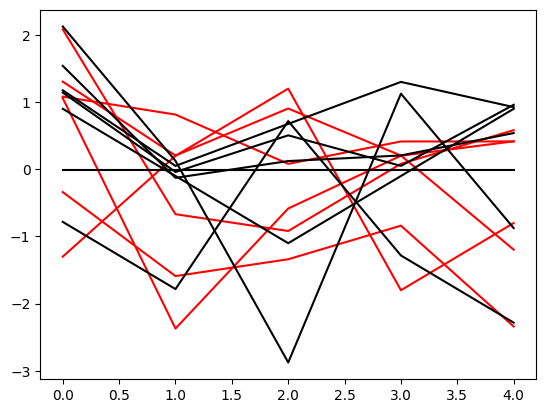

In [21]:
fig, ax = plt.subplots()

chan0_mu, chan1_mu = [], []
for mouse in sparse_mice:
    chan0_mu.append(argmax_dict[mouse][day]['nov']['channel_0'])
    chan1_mu.append(argmax_dict[mouse][day]['nov']['channel_1'])
chan0_mu, chan1_mu = np.squeeze(np.array(chan0_mu)), np.squeeze(np.array(chan1_mu))

ax.plot(x, chan0_mu.T, color='red')
ax.plot(x, chan1_mu.T, color='black')


-1.2999999999999998 0.9000000000000004
1.1235006823242117 -0.7828054298642537
-0.21666666666666656 1.0946558704453442
0.8755102040816327 0.13031674208144803
-5.64 nan
nan 1.323421912624699
nan 2.125


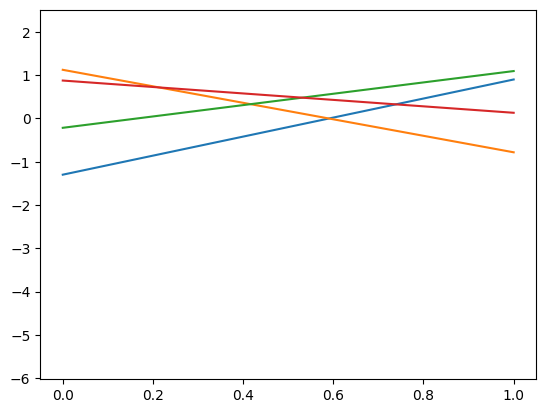

In [16]:
fig,ax=plt.subplots()
for ch0, ch1 in zip(chan0_mu[:,0], chan1_mu[:,0]):
    print(ch0, ch1)
    ax.plot([0,1], [ch0,ch1])

In [41]:
sp.stats.wilcoxon(chan0_mu[:,0]-chan1_mu[:,0])

WilcoxonResult(statistic=np.float64(nan), pvalue=np.float64(nan))